# Business Understanding

## Project Domain

Proyek ini berada dalam domain Meteorologi dan Prediksi Cuaca, yang bertujuan untuk memanfaatkan data historis cuaca dalam membangun model prediksi suhu maksimum menggunakan teknik pembelajaran mesin, khususnya deep learning (LSTM). Informasi ini penting untuk berbagai sektor seperti pertanian, pariwisata, transportasi, dan kesehatan masyarakat.

## Problem Statements

Fluktuasi cuaca yang tidak menentu di kota Seattle dapat menyebabkan ketidakpastian dalam perencanaan aktivitas harian dan ekonomi. Namun, informasi suhu yang akurat tidak selalu tersedia secara real-time atau dengan akurasi yang tinggi. Oleh karena itu, dibutuhkan sebuah model yang mampu memprediksi suhu maksimum harian berdasarkan data cuaca historis, termasuk suhu minimum, curah hujan, kecepatan angin, dan kondisi cuaca.

## Goals

Menganalisis dataset cuaca Seattle dan mengidentifikasi pola dari variabel cuaca.

Mengembangkan model prediktif berbasis deep learning (LSTM) untuk memprediksi suhu maksimum harian.

Mengevaluasi performa model berdasarkan metrik regresi (MSE, MAE, R²).

Mengkategorikan hasil prediksi suhu ke dalam label seperti Dingin, Sedang, dan Panas untuk keperluan klasifikasi praktis.

## Solution Statements

Eksplorasi dan praproses data: normalisasi fitur numerik, encoding fitur kategorikal.

Pengembangan model deep learning menggunakan LSTM, yang cocok untuk menangkap pola urutan dan dependensi waktu dari data cuaca.

Evaluasi model menggunakan MAE, MSE, dan R², serta konversi hasil prediksi ke dalam kategori untuk kebutuhan interpretasi praktis.

Penerapan model untuk prediksi suhu maksimum dari data baru, dengan tujuan implementasi nyata seperti sistem peringatan dini atau aplikasi perencanaan cuaca.

# Data Understanding

## Import data dari kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hargriv","key":"df8fa4e2261acde876813122e7a1b16c"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [ ]:
!kaggle datasets download -d ananthr1/weather-prediction

Dataset URL: https://www.kaggle.com/datasets/ananthr1/weather-prediction
License(s): CC-BY-NC-SA-4.0


In [ ]:
!mkdir weather-prediction-dataset
!unzip weather-prediction.zip -d weather-prediction-dataset
!ls weather-prediction-dataset

Archive:  weather-prediction.zip
  inflating: weather-prediction-dataset/seattle-weather.csv  
seattle-weather.csv


## Import Library yang dibutuhkan

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers

import tensorflow as tf
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras import Sequential
from tensorflow.keras.optimizers import Adam

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import r2_score

## Exploratory Data Analysis

In [ ]:
df = pd.read_csv('weather-prediction-dataset/seattle-weather.csv')
print(df.head())

         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-02           10.9      10.6       2.8   4.5     rain
2  2012-01-03            0.8      11.7       7.2   2.3     rain
3  2012-01-04           20.3      12.2       5.6   4.7     rain
4  2012-01-05            1.3       8.9       2.8   6.1     rain


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


In [ ]:
df.describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


In [ ]:
df['date'] = pd.to_datetime(df['date'])

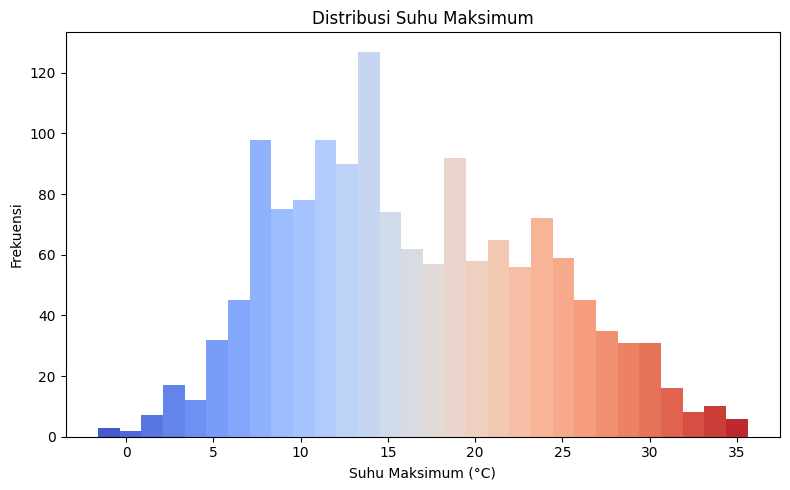

In [ ]:
# 1. Histogram Suhu Maksimum
plt.figure(figsize=(8, 5))
counts, bins = np.histogram(df['temp_max'], bins=30)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
colors = sns.color_palette("coolwarm", len(counts))
for count, x, c in zip(counts, bin_centers, colors):
    plt.bar(x, count, width=(bins[1]-bins[0]), color=c, align='center')
plt.title('Distribusi Suhu Maksimum')
plt.xlabel('Suhu Maksimum (°C)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

<ipython-input-11-bdd04329182c>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='weather', y='temp_min', data=df, palette='Set3')


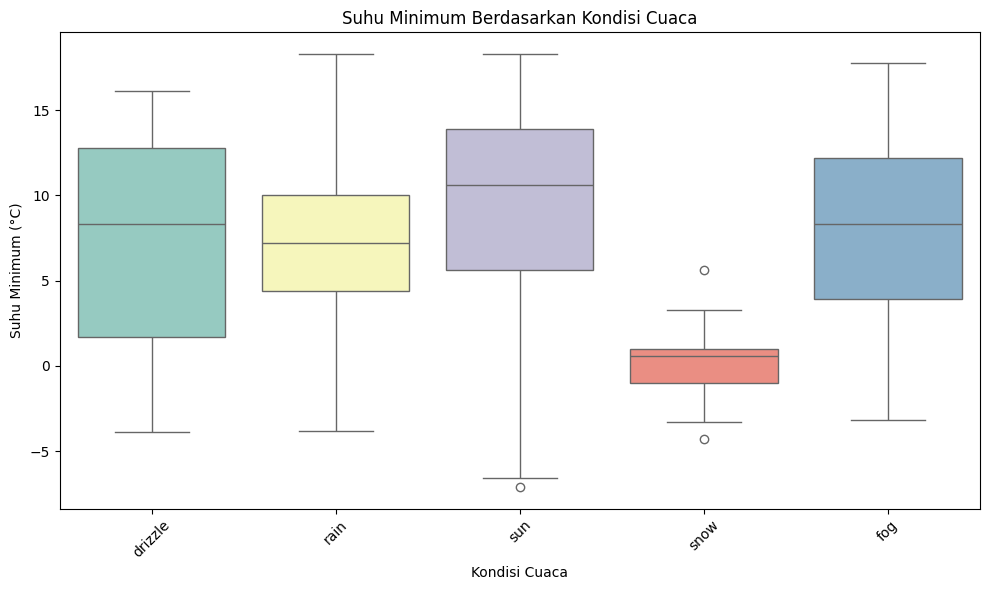

In [ ]:
# 2. Boxplot Suhu Minimum Berdasarkan Kondisi Cuaca
plt.figure(figsize=(10, 6))
sns.boxplot(x='weather', y='temp_min', data=df, palette='Set3')
plt.title('Suhu Minimum Berdasarkan Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Suhu Minimum (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

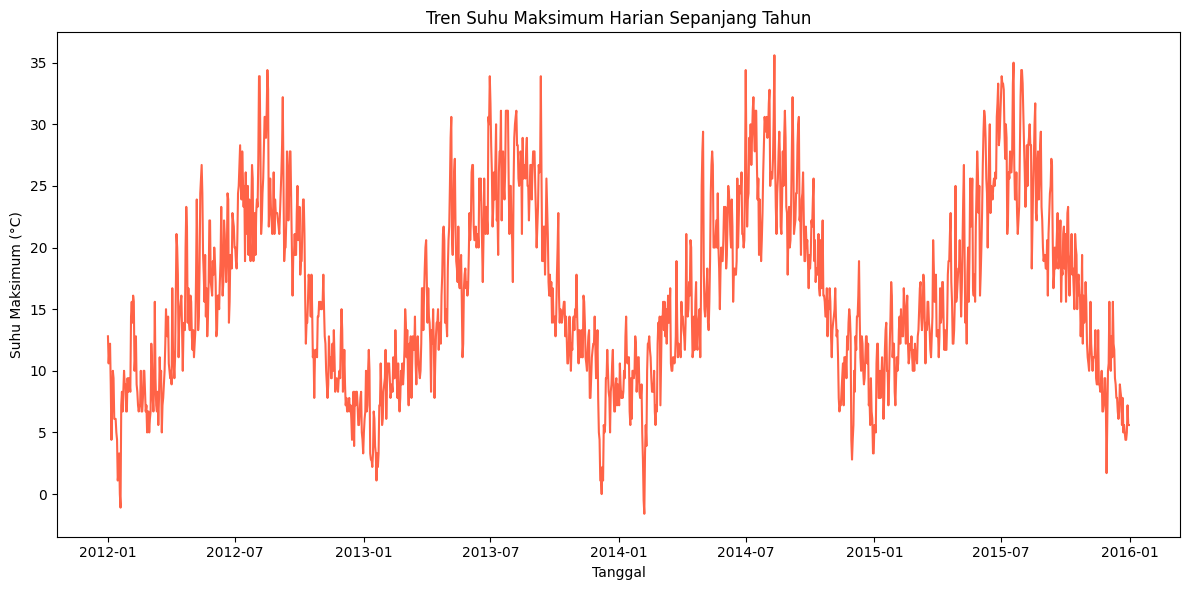

In [ ]:
# 3. Garis Waktu Suhu Maksimum Sepanjang Tahun
plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='temp_max', data=df, color='tomato')
plt.title('Tren Suhu Maksimum Harian Sepanjang Tahun')
plt.xlabel('Tanggal')
plt.ylabel('Suhu Maksimum (°C)')
plt.tight_layout()
plt.show()

<ipython-input-13-2d9f6fbc2239>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='weather', data=df, palette='muted')


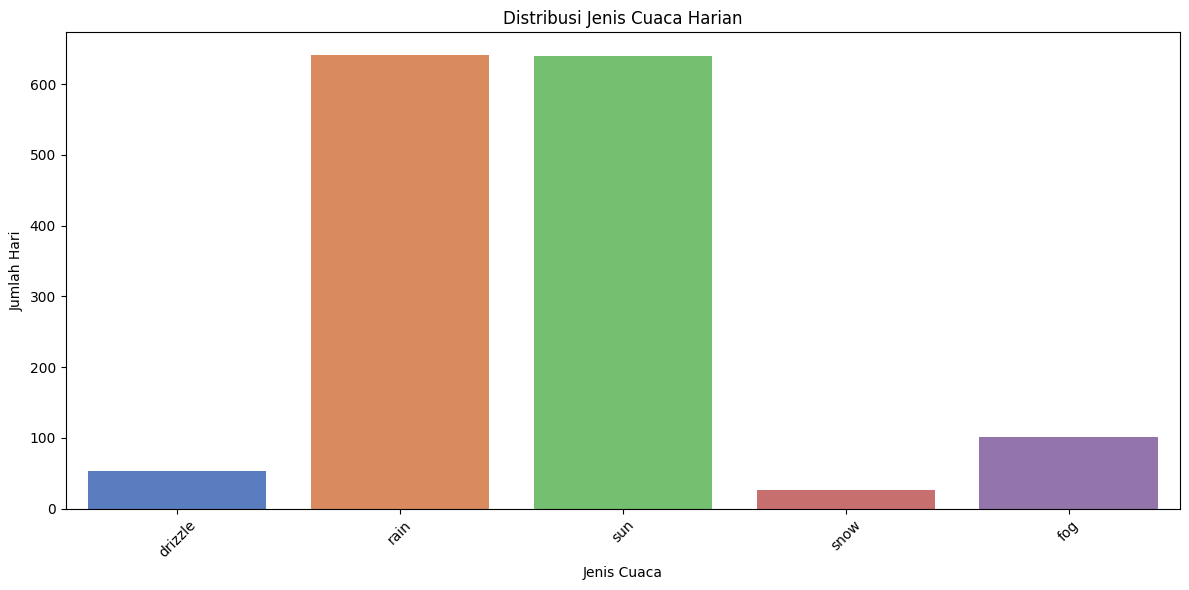

In [ ]:
# 4. Distribusi Jenis Cuaca
plt.figure(figsize=(12, 6))
sns.countplot(x='weather', data=df, palette='muted')
plt.title('Distribusi Jenis Cuaca Harian')
plt.xlabel('Jenis Cuaca')
plt.ylabel('Jumlah Hari')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

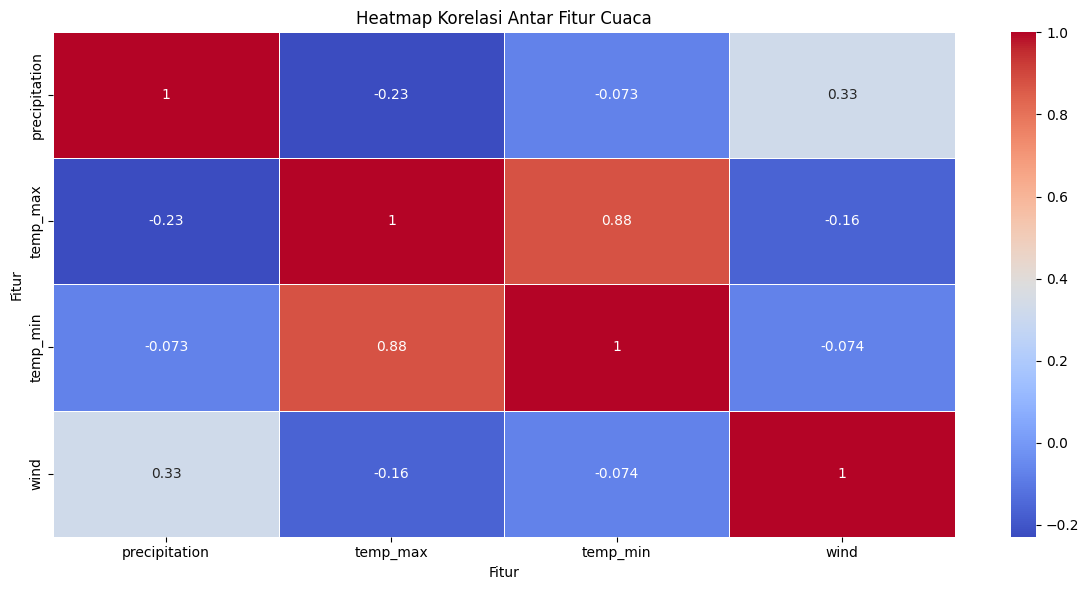

In [ ]:
# 5. Heatmap Korelasi Antar Fitur Cuaca
plt.figure(figsize=(12, 6))
sns.heatmap(df[['precipitation', 'temp_max', 'temp_min', 'wind']].corr(),
            annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur Cuaca')
plt.xlabel('Fitur')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

# Data Preparation

In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
df = df.drop('date', axis=1)

In [ ]:
y = df['temp_max']
X = df.drop('temp_max', axis=1)

In [ ]:
X = pd.get_dummies(X, columns=['weather'], drop_first=True)

In [ ]:
numerical_features = ['precipitation', 'temp_min', 'wind']
scaler = MinMaxScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

In [ ]:
X.head(), y.head()

(   precipitation  temp_min      wind  weather_fog  weather_rain  weather_snow  \
 0       0.000000  0.476378  0.472527        False         False         False   
 1       0.194991  0.389764  0.450549        False          True         False   
 2       0.014311  0.562992  0.208791        False          True         False   
 3       0.363148  0.500000  0.472527        False          True         False   
 4       0.023256  0.389764  0.626374        False          True         False   
 
    weather_sun  
 0        False  
 1        False  
 2        False  
 3        False  
 4        False  ,
 0    12.8
 1    10.6
 2    11.7
 3    12.2
 4     8.9
 Name: temp_max, dtype: float64)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Ensure all features are numeric before reshaping for LSTM
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

# Reshape for LSTM
X_train_lstm = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_lstm = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

# Modeling

In [ ]:
# Define the model
model = Sequential([
    layers.LSTM(64, activation="relu", return_sequences=True, input_shape=(X_train.shape[1], 1)),
    layers.LSTM(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="linear")
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss="mean_squared_error", metrics=["mae"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Fit the model
history = model.fit(X_train_lstm, y_train, epochs=50, batch_size=32, validation_data=(X_test_lstm, y_test))

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 316.6552 - mae: 16.2775 - val_loss: 260.8094 - val_mae: 14.3126
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 136.2871 - mae: 9.6111 - val_loss: 57.7668 - val_mae: 6.2994
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 52.7795 - mae: 6.0673 - val_loss: 49.9430 - val_mae: 5.9768
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 46.8394 - mae: 5.7473 - val_loss: 45.2751 - val_mae: 5.8305
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 39.4113 - mae: 5.2690 - val_loss: 38.6729 - val_mae: 5.3308
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 36.6267 - mae: 5.0393 - val_loss: 31.3732 - val_mae: 4.6615
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 32.0370 - mae: 4.5573 - val_loss: 23.8854 - val_mae: 3.9874
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 24.2217 - mae: 3.9211 - val_loss: 22.9096 - val_mae: 3.8378
Epoch 9/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12

# Evaluation

In [ ]:
# Evaluasi model
test_loss, test_mae = model.evaluate(X_test_lstm, y_test, verbose=1)
print(f"Mean Absolute Error: {test_mae:.4f}")
print(f"Loss Model (MSE): {test_loss:.4f}")

# Since this is a regression problem, 'accuracy' is not a standard metric.
# Instead, we can calculate R-squared to evaluate the model's performance.
r_squared = r2_score(y_test, model.predict(X_test_lstm))
print(f"R-squared: {r_squared:.2%}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.5053 - mae: 2.5088 
Mean Absolute Error: 2.4490
Loss Model (MSE): 9.1604
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
R-squared: 83.90%


In [ ]:
# Visualisasi akurasi & loss
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

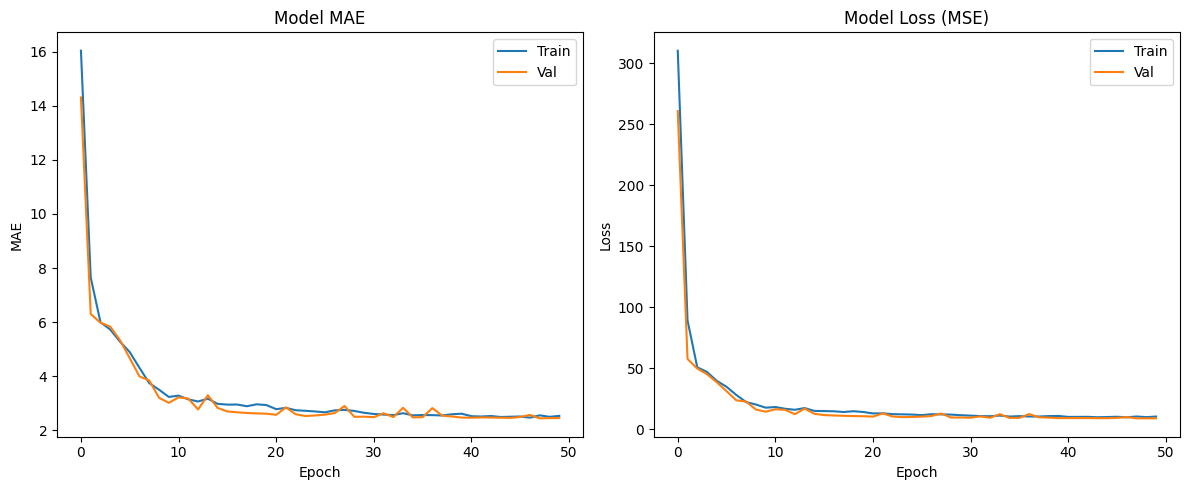

In [ ]:
# Visualisasi akurasi & loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('Model MAE')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss (MSE)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.tight_layout()
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


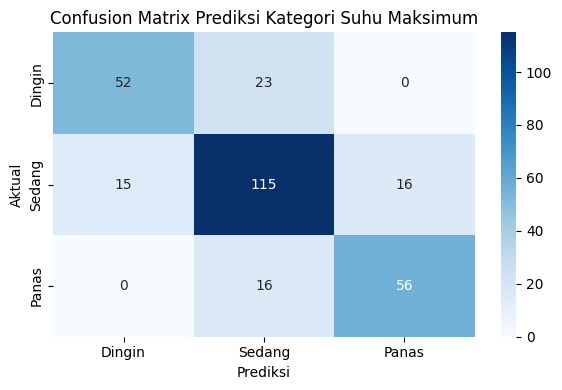

              precision    recall  f1-score   support

      Dingin       0.78      0.69      0.73        75
      Sedang       0.78      0.78      0.78        72
       Panas       0.75      0.79      0.77       146

    accuracy                           0.76       293
   macro avg       0.77      0.75      0.76       293
weighted avg       0.76      0.76      0.76       293



In [ ]:
# Prediksi nilai suhu
y_pred = model.predict(X_test_lstm).flatten()

# Buat kategori suhu aktual dan prediksi
bins = [0, np.percentile(y_test, 25), np.percentile(y_test, 75), np.max(y_test)]
labels = ['Dingin', 'Sedang', 'Panas']

y_actual_categories = pd.cut(y_test, bins=bins, labels=labels, include_lowest=True)
y_predicted_categories = pd.cut(y_pred, bins=bins, labels=labels, include_lowest=True)

# Matriks kebingungan
conf_matrix = confusion_matrix(y_actual_categories, y_predicted_categories, labels=labels)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix Prediksi Kategori Suhu Maksimum")
plt.tight_layout()
plt.show()

# Classification Report
print(classification_report(y_actual_categories, y_predicted_categories, target_names=labels))


# Deployment

## Model Simulation

In [ ]:
# Contoh data cuaca baru untuk diprediksi
new_data = pd.DataFrame({
    'precipitation': [0.1],
    'temp_min': [5.0],
    'wind': [2.5],
    'weather_drizzle': [0],
    'weather_fog': [0],
    'weather_rain': [1],
    'weather_snow': [0]
})

In [ ]:
# Define the numerical features for scaling (excluding temp_max)
numerical_features = ['precipitation', 'temp_min', 'wind']

# Create a new DataFrame with only the numerical features from new_data
new_data_numerical = new_data[numerical_features]

# Fit the scaler on only the numerical features used in the new data
scaler.fit(new_data_numerical) # Fit the scaler on the new data's numerical features

# Now apply the transform method
new_data[numerical_features] = scaler.transform(new_data_numerical)

In [ ]:
# Ubah ke format input untuk LSTM (samples, timesteps, features)
new_data_lstm = new_data.astype(np.float32).values.reshape(new_data.shape[0], new_data.shape[1], 1)

In [ ]:
# Prediksi suhu maksimum
predicted_temp = model.predict(new_data_lstm)
print(f"Suhu Maksimum yang Diprediksi: {predicted_temp[0][0]:.2f}°C")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Suhu Maksimum yang Diprediksi: 3.38°C


## Save Model

In [ ]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Aktifkan resource variables dan dukungan ops TensorFlow jika diperlukan
converter.experimental_enable_resource_variables = True
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

# Simpan model dalam format .tflite
with open('weather_temperature_prediction_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("✅ Model berhasil dikonversi dan disimpan sebagai 'weather_temperature_prediction_model.tflite'")


Saved artifact at '/tmp/tmpsn8q6o_p'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 7, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134623575758352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134623575759312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134623575761232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134623575761424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134623575757200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134623575759120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134623575761616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134623575762960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134623575761040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134623575763728: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ Model berhasil dikonv

In [ ]:
import pickle

# Simpan scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Scaler berhasil disimpan sebagai 'scaler.pkl'")


✅ Scaler berhasil disimpan sebagai 'scaler.pkl'
